In [75]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# **1. Загрузите изображение в оттенках серого sar_1_gray.jpg.**

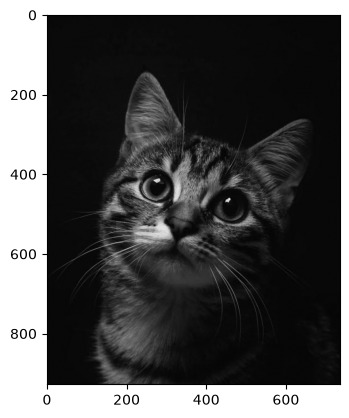

In [76]:
image_gray = cv2.imread('cat1.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(image_gray, cmap='gray')
plt.show()

# **2. Постройте гистограмму**

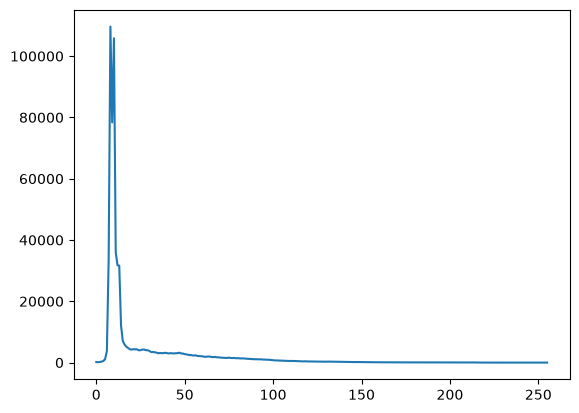

In [77]:
histSize = 256
histRange = (0, 256)
accumulate = False

gray_hist = cv2.calcHist([image_gray], [0], None, [histSize], histRange, accumulate=accumulate)
plt.plot(gray_hist)
plt.show()

# **3. Реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.**

In [78]:
def gamma_correction(image, gamma):
    normalized = image / 255.0
    corrected = np.power(normalized, gamma)
    result = np.uint8(corrected * 255)
    return result

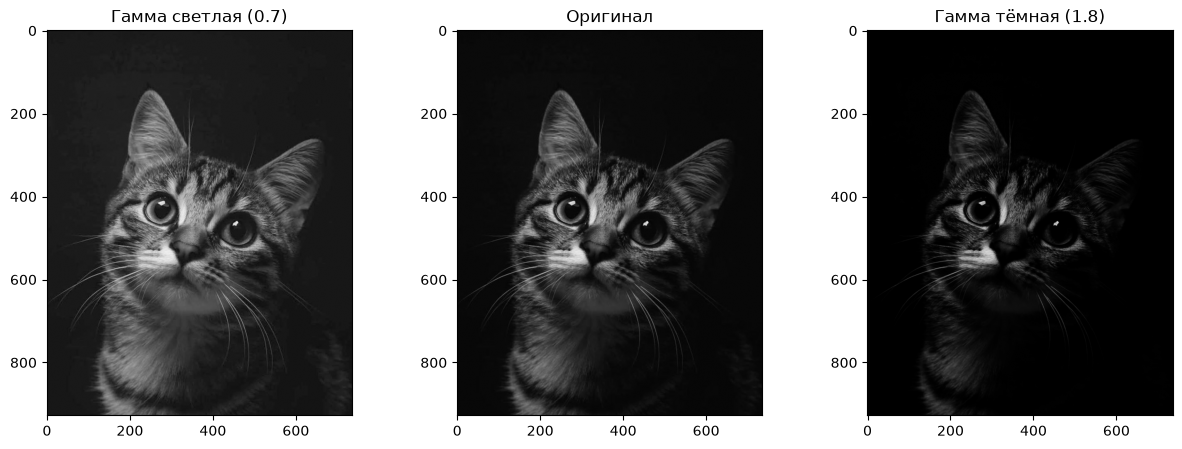

In [79]:
# светлая 
gamma_light = 0.7
image_gamma_light = gamma_correction(image_gray, gamma_light)

# тёмная 
gamma_dark = 1.8
image_gamma_dark = gamma_correction(image_gray, gamma_dark)

# все картинки в ряд
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[1].imshow(image_gray, cmap='gray')
axs[1].set_title('Оригинал')

axs[0].imshow(image_gamma_light, cmap='gray')
axs[0].set_title(f'Гамма светлая ({gamma_light})')

axs[2].imshow(image_gamma_dark, cmap='gray')
axs[2].set_title(f'Гамма тёмная ({gamma_dark})')

plt.show()

# **4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.**

Оригинал vs гамма < 1:
	SSIM: 0.736
	MSE: 441.272

Оригинал vs гамма > 1:
	SSIM: 0.224
	MSE: 525.180


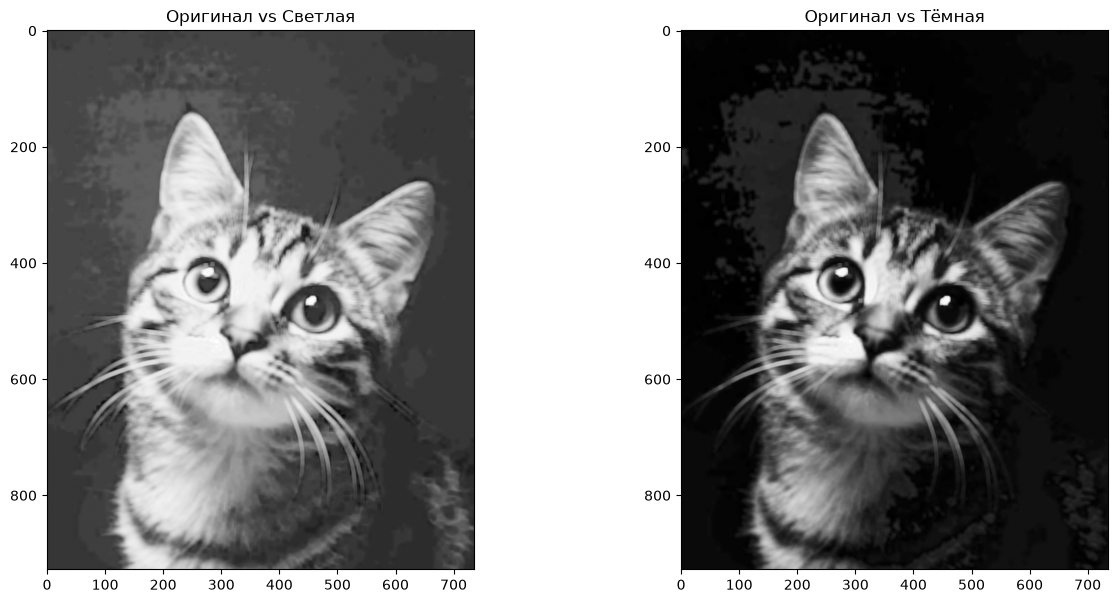

In [80]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim_l, diff_l) = structural_similarity(image_gray, image_gamma_light, full=True)
diff_l = (diff_l * 255).astype("uint8")
mse_l = mean_squared_error(image_gray, image_gamma_light)

print("Оригинал vs гамма < 1:")
print(f"\tSSIM: {ssim_l:.3f}")
print(f"\tMSE: {mse_l:.3f}")

print()

(ssim_r, diff_r) = structural_similarity(image_gray, image_gamma_dark, full=True)
diff_r = (diff_r * 255).astype("uint8")
mse_r = mean_squared_error(image_gray, image_gamma_dark)

print("Оригинал vs гамма > 1:")
print(f"\tSSIM: {ssim_r:.3f}")
print(f"\tMSE: {mse_r:.3f}")

fig, axs = plt.subplots(1, 2, figsize=(15, 7))
axs[0].imshow(diff_l, cmap='gray')
axs[0].set_title('Оригинал vs Светлая')

axs[1].imshow(diff_r, cmap='gray')
axs[1].set_title('Оригинал vs Тёмная')

plt.show()


# **5. Реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.**

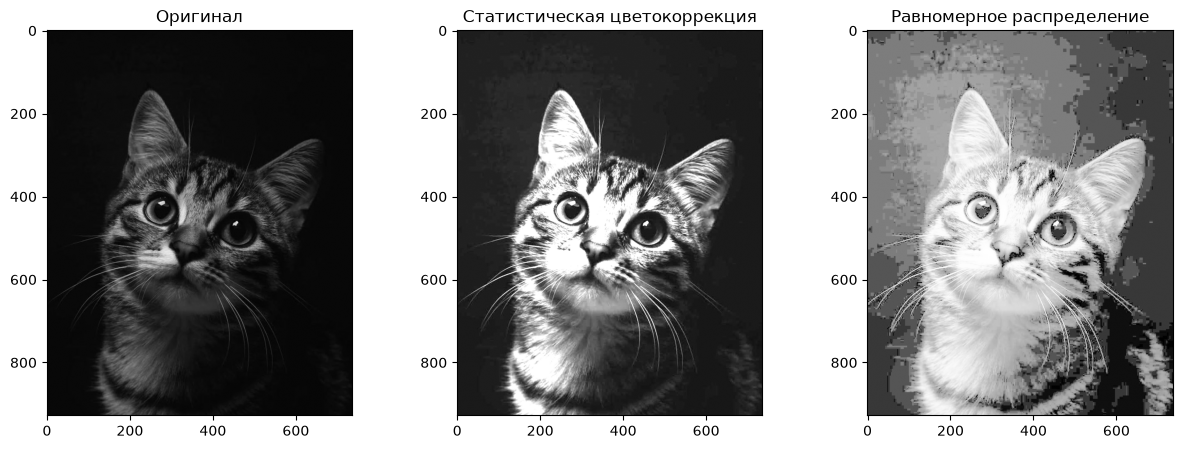

In [81]:
def statistical_color_correction(image, reference):
    mean_src, std_src = image.mean(), image.std()
    mean_ref, std_ref, = reference.mean(), reference.std()

    corrected = (image - mean_src) * (std_ref / std_src) + mean_ref
    corrected = np.clip(corrected, 0, 255).astype(np.uint8)
    return corrected

eq_gray = cv2.equalizeHist(image_gray)
image_corrected = statistical_color_correction(image_gray, eq_gray)


fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(image_gray, cmap='gray')
axs[0].set_title('Оригинал')

axs[1].imshow(image_corrected, cmap='gray')
axs[1].set_title('Статистическая цветокоррекция')

axs[2].imshow(eq_gray, cmap='gray')
axs[2].set_title('Равномерное распределение')

plt.show()

Равномерное распределение vs Статистическая цветокоррекция
	SSIM: 0.694
	MSE: 1526.253


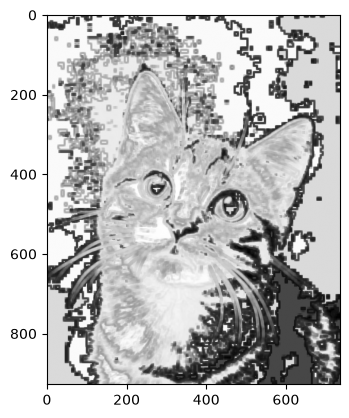

In [82]:
(ssim, diff) = structural_similarity(image_corrected, eq_gray, full=True)
diff = (diff * 255).astype("uint8")
print("Равномерное распределение vs Статистическая цветокоррекция")
print(f"\tSSIM: {ssim:.3f}")
print(f"\tMSE: {mean_squared_error(image_corrected, eq_gray):.3f}")

plt.imshow(diff, cmap="gray")

# **6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.**

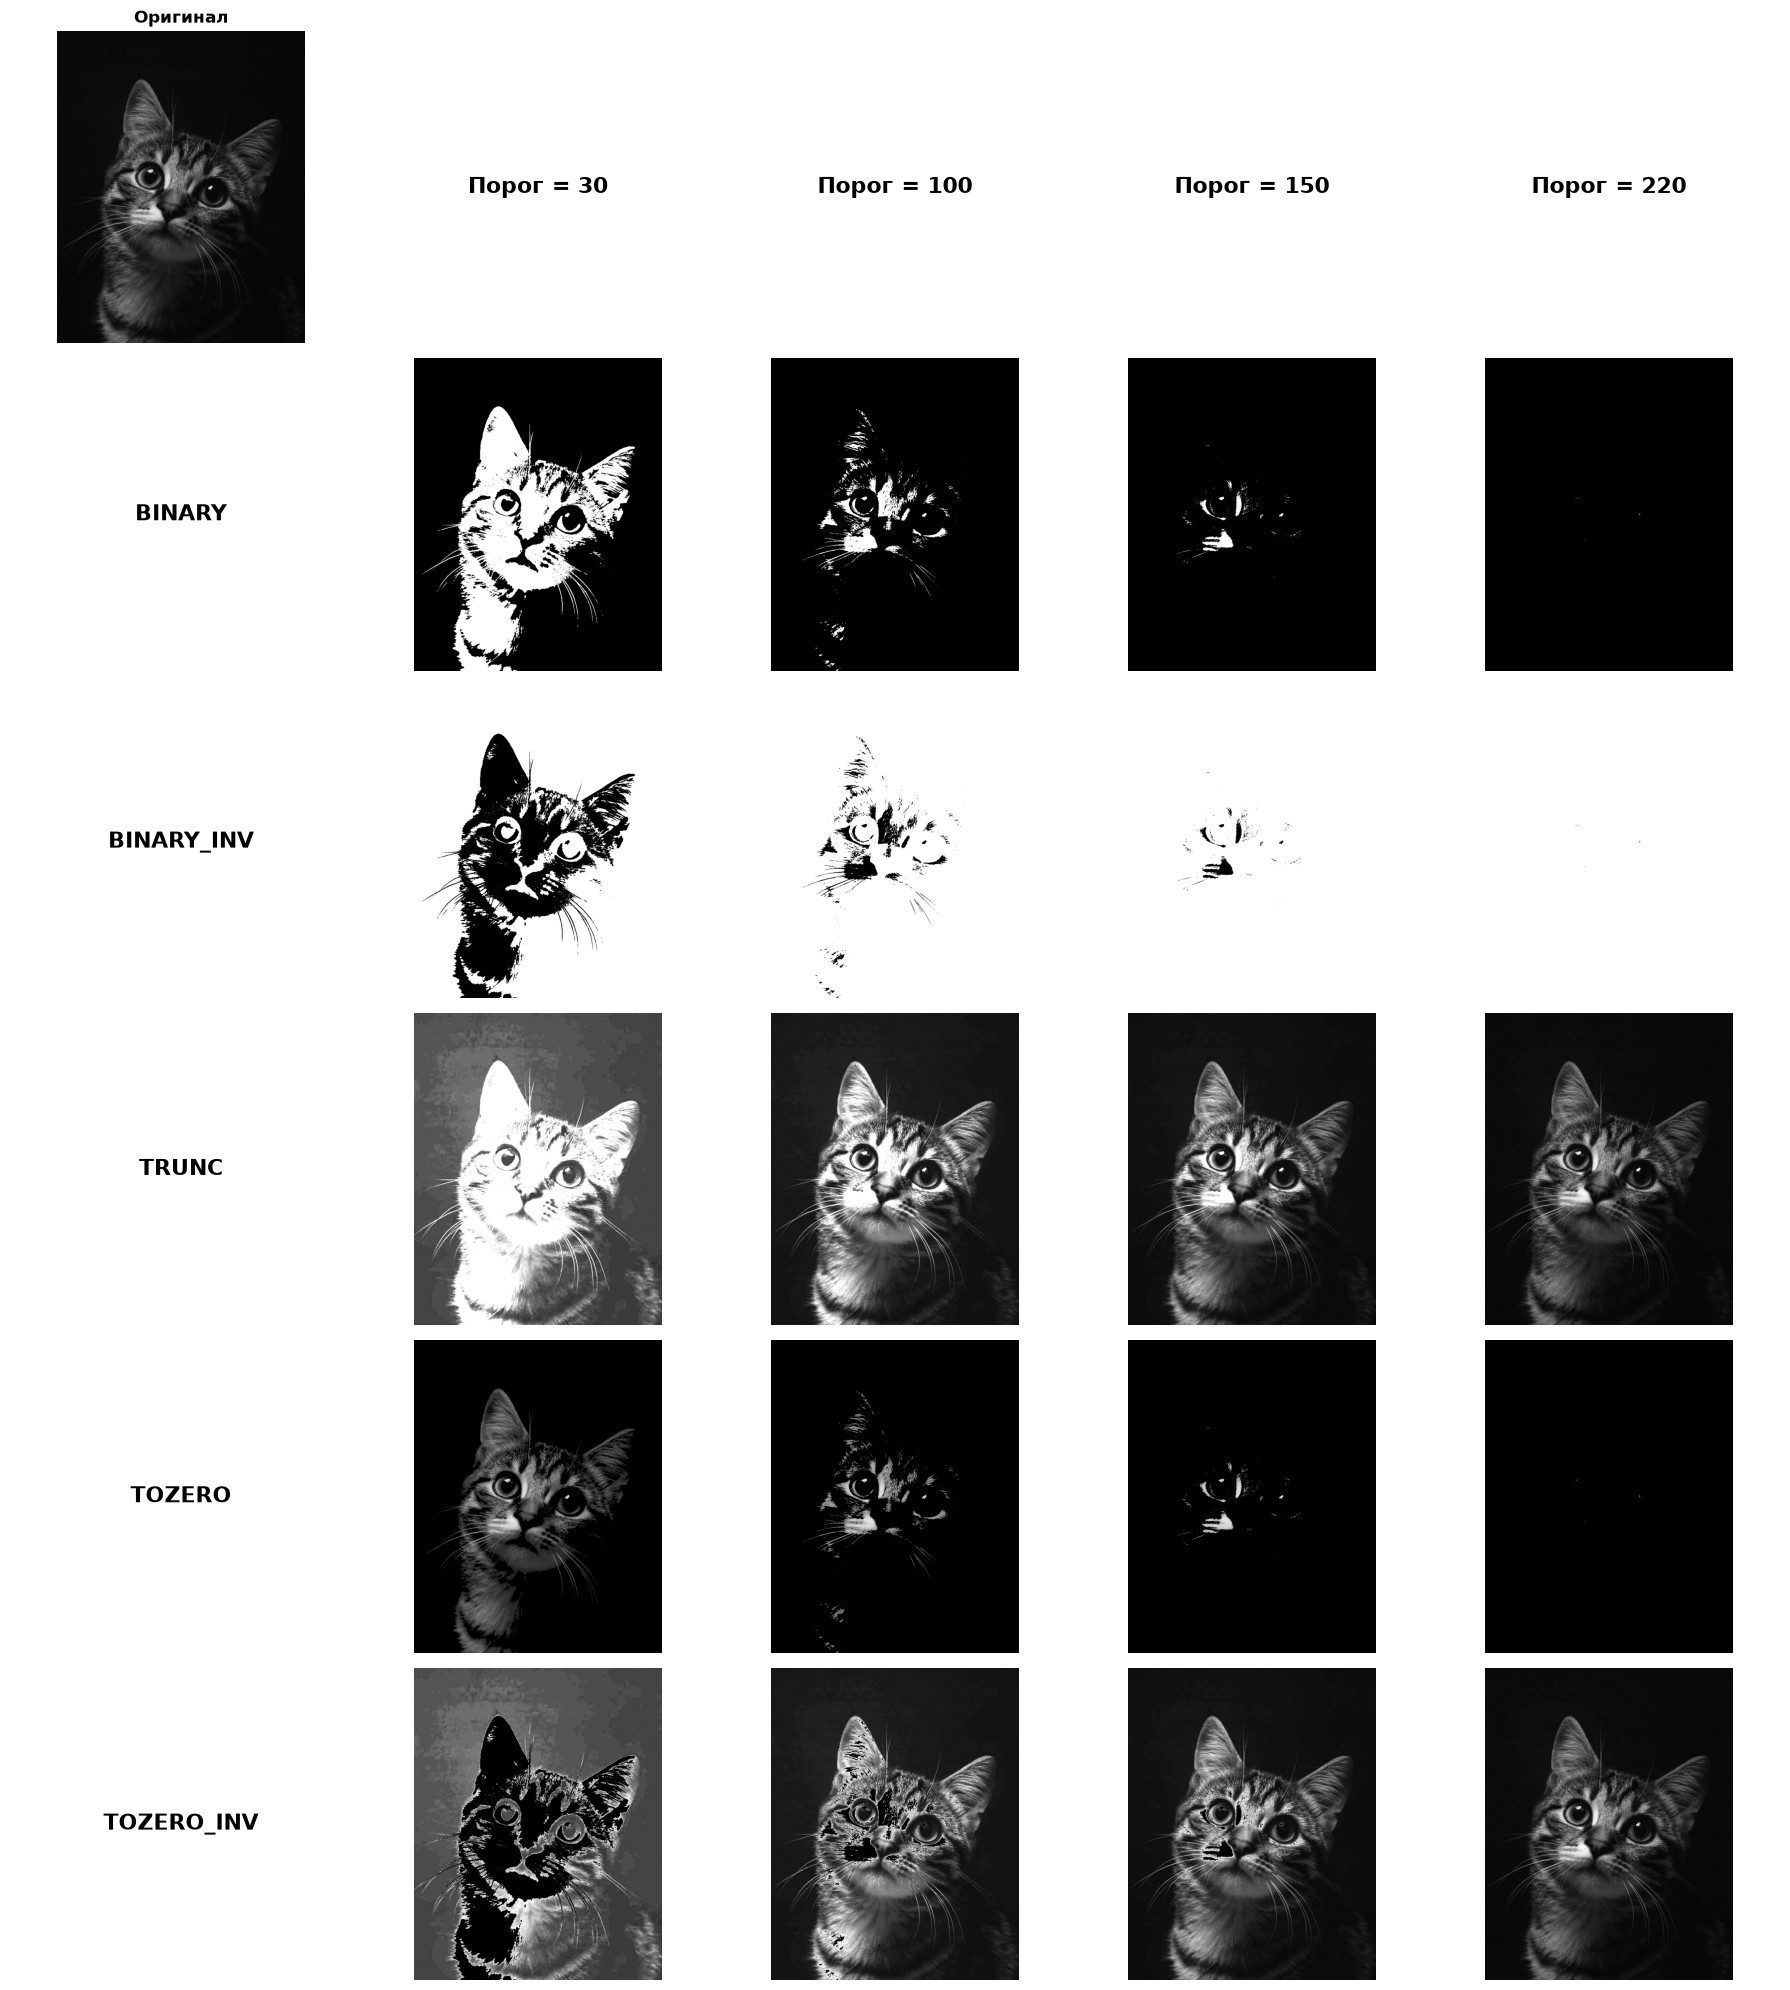

In [83]:
thresholds = [30, 100, 150, 220]

modes = [
    (cv2.THRESH_BINARY,     'BINARY'),
    (cv2.THRESH_BINARY_INV, 'BINARY_INV'),
    (cv2.THRESH_TRUNC,      'TRUNC'),
    (cv2.THRESH_TOZERO,     'TOZERO'),
    (cv2.THRESH_TOZERO_INV, 'TOZERO_INV'),
]

fig, axes = plt.subplots(len(modes) + 1, len(thresholds) + 1, figsize=(18, 20))

axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title('Оригинал', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

for j, thresh in enumerate(thresholds):
    axes[0, j + 1].text(0.5, 0.5, f'Порог = {thresh}',
                         ha='center', va='center',
                         fontsize=16, fontweight='bold')
    axes[0, j + 1].axis('off')

for i, (mode, mode_name) in enumerate(modes):

    axes[i + 1, 0].text(0.5, 0.5, mode_name,
                         ha='center', va='center',
                         fontsize=16, fontweight='bold')
    axes[i + 1, 0].axis('off')

    for j, thresh in enumerate(thresholds):
        _, result = cv2.threshold(image_gray, thresh, 255, mode)
        axes[i + 1, j + 1].imshow(result, cmap='gray')
        axes[i + 1, j + 1].axis('off')

plt.tight_layout()
plt.show()